<a href="https://colab.research.google.com/github/Kireeti2808/agri_doctor/blob/main/rice_h5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 161M/161M [00:01<00:00, 156MB/s]

Extracting files...


Loading images...
Found 4188 files belonging to 4 classes.
Classes found: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
Starting Training...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 462s 4s/step - accuracy: 0.6537 - loss: 0.8179 - val_accuracy: 0.8221 - val_loss: 0.3946
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 442s 4s/step - accuracy: 0.8452 - loss: 0.3864 - val_accuracy: 0.8558 - val_loss: 0.3229
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 427s 4s/step - accuracy: 0.8516 - loss: 0.3714 - val_accuracy: 0.8486 - val_loss: 0.3631
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 435s 4s/step - accuracy: 0.8570 - loss: 0.3582 - val_accuracy: 0.8365 - val_loss: 0.3712
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 426s 4s/step - accuracy: 0.8595 - loss: 0.3386 - val_accuracy: 0.8630 - val_loss: 0.3027
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 427s 4s/step - accuracy: 0.8603 - loss: 0.3453 - val_accuracy: 0.8798 - val_loss: 0.2780
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 426s 4s/step - accuracy: 0.8681 - loss: 0.3083 - val_accuracy: 0.8774 - val_loss: 0.2891
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 425s 4s/step - accuracy: 0.8844 - loss: 0.2871 - val_accuracy: 0.884

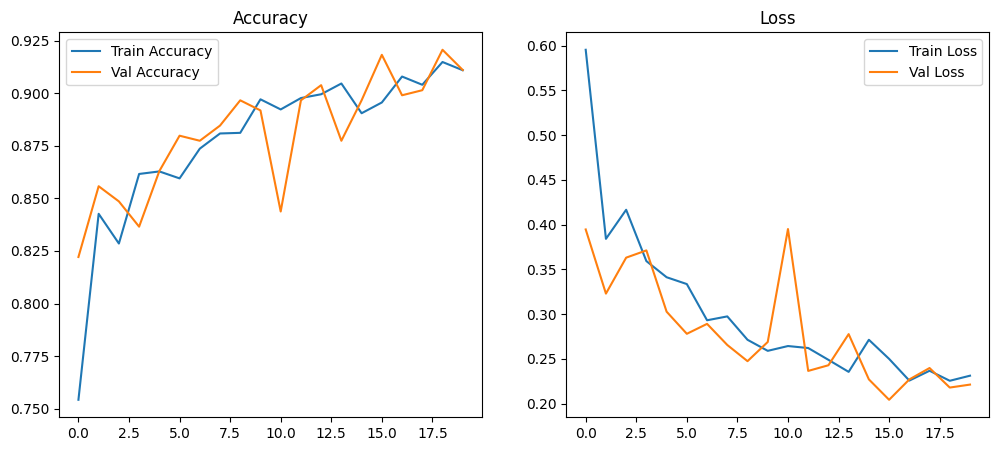

Evaluating on Test Data...
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9283 - loss: 0.1940
Final Test Accuracy: 93.08%


In [ ]:
# 1. INSTALL & IMPORT LIBRARIES
!pip install -q kagglehub
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import os
import kagglehub
import numpy as np

# 2. DOWNLOAD DATASET (Directly from Kaggle to Colab)
print("Downloading Maize Dataset...")
path = kagglehub.dataset_download("smaranjitghose/corn-or-maize-leaf-disease-dataset")
# The dataset has a 'data' subfolder
dataset_path = os.path.join(path, "data")

# 3. SETTINGS
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 20

# 4. LOAD IMAGES
print("Loading images...")
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print(f"Classes found: {class_names}")

# 5. SPLIT DATA (80% Train, 10% Val, 10% Test)
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

# Optimize performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# 6. BUILD MODEL (CNN Architecture)
model = models.Sequential([
    layers.Rescaling(1.0/255, input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# 7. TRAIN
print("Starting Training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

# 8. VISUALIZE RESULTS
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Train Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Train Loss')
plt.plot(range(EPOCHS), val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 9. FINAL EVALUATION
print("Evaluating on Test Data...")
scores = model.evaluate(test_ds)
print(f"Final Test Accuracy: {scores[1]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


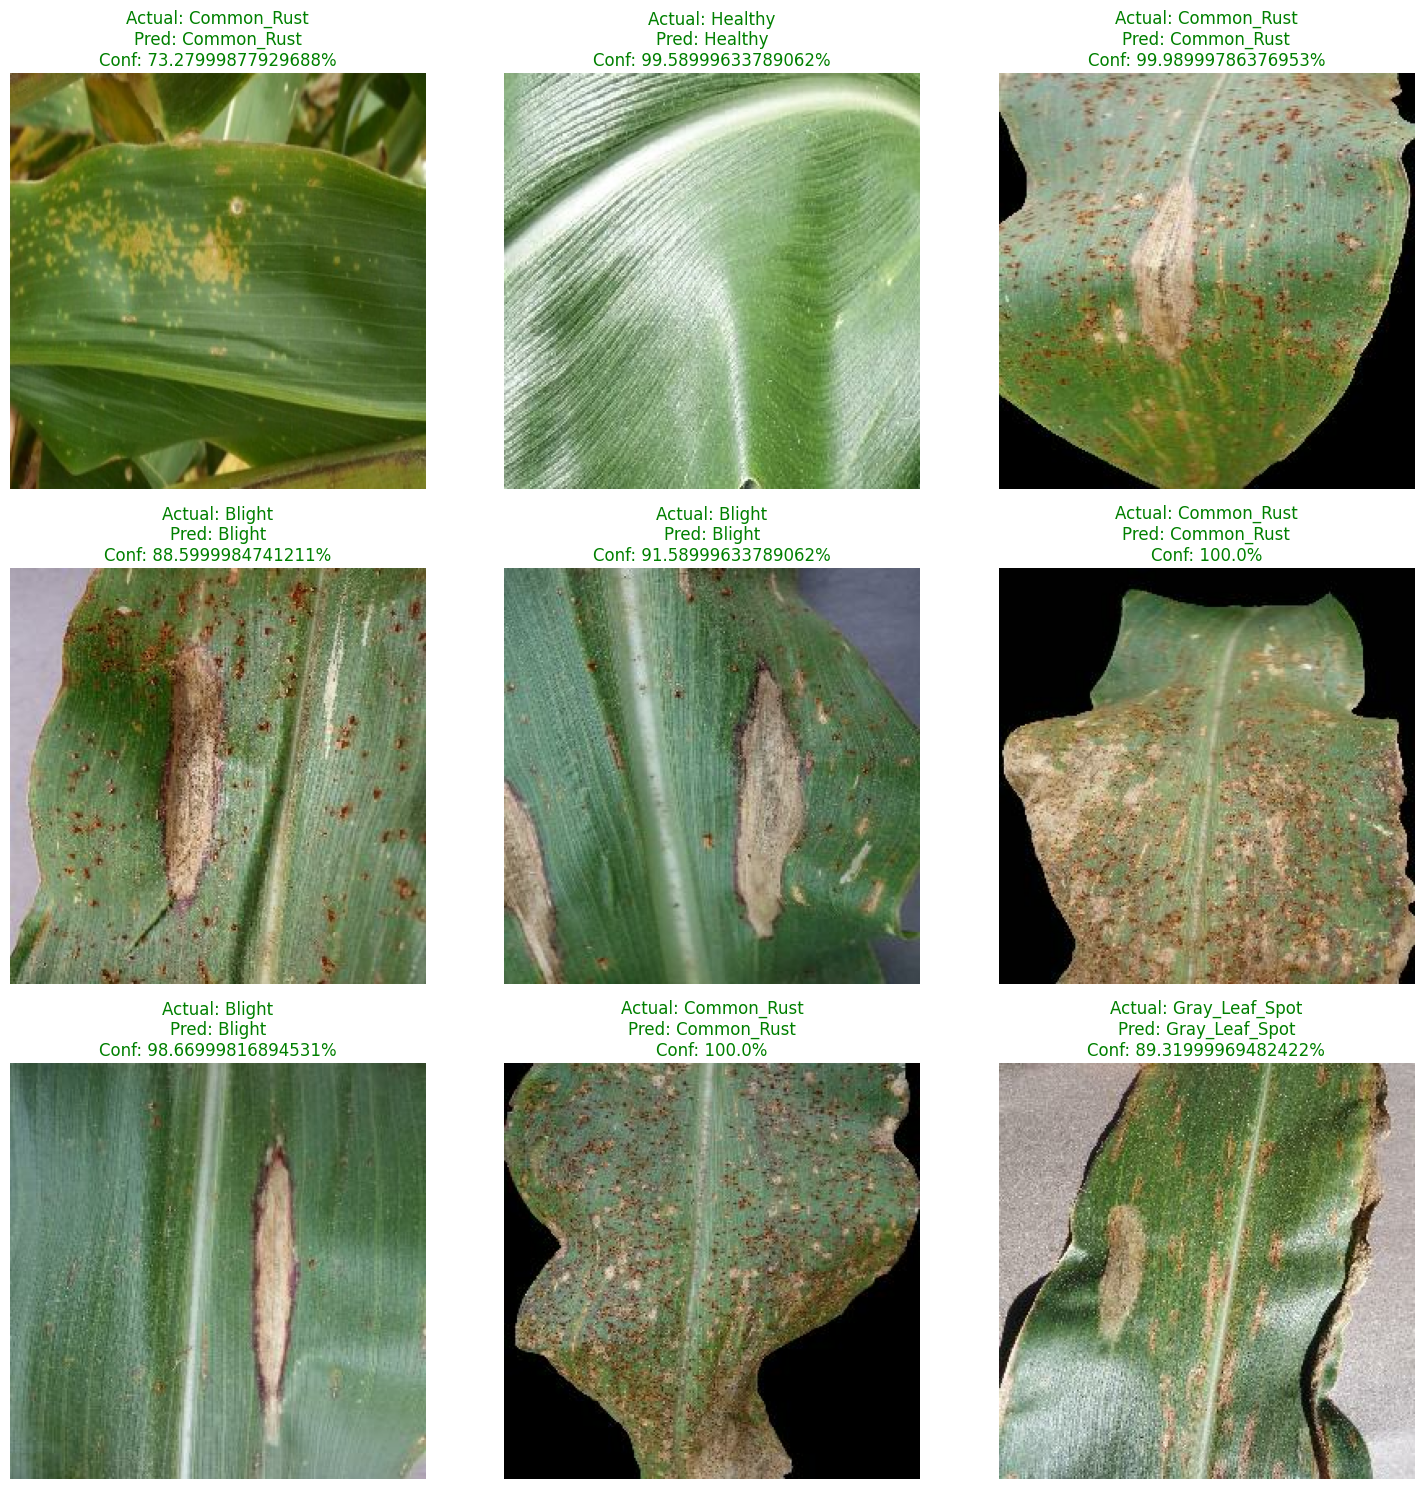

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure for our 3x3 grid
plt.figure(figsize=(15, 15))

# Take one batch from the test dataset (usually 32 images)
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Display the image (un-normalize it if it was scaled)
        # If your model used 1./255 scaling, we just show the original pixels
        plt.imshow(images[i].numpy().astype("uint8"))

        # Prepare image for prediction (add batch dimension)
        img_array = tf.expand_dims(images[i], 0)

        # Get the prediction array
        predictions = model.predict(img_array)

        # Find the index of the highest confidence score
        predicted_class = class_names[np.argmax(predictions[0])]
        actual_class = class_names[labels[i]]
        confidence = round(100 * (np.max(predictions[0])), 2)

        # Define color: Green for correct, Red for wrong
        title_color = "green" if predicted_class == actual_class else "red"

        plt.title(f"Actual: {actual_class}\nPred: {predicted_class}\nConf: {confidence}%",
                  color=title_color, fontsize=12)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Save in the legacy H5 format
model.save("rice_expert_v1.h5")

# Download it to your computer
from google.colab import files
files.download("rice_expert_v1.h5")
print("Saved and downloading as .h5 boiii!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloading as .h5 boiii!


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


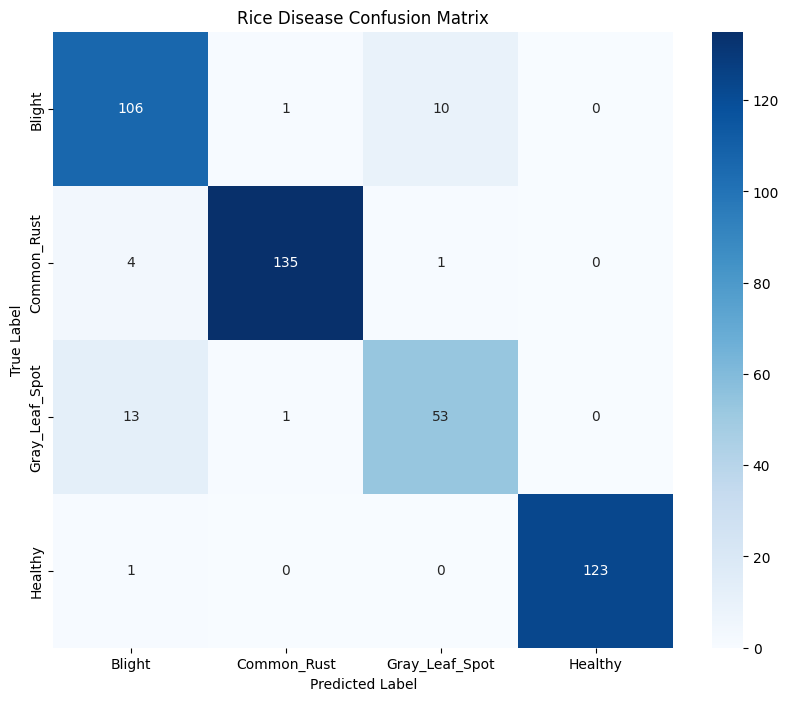

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get all the true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend([np.argmax(p) for p in preds])

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Rice Disease Confusion Matrix')
plt.show()


In [ ]:
# ==========================================
# 0. INSTALL & IMPORTS
# ==========================================
!pip install -q kagglehub scikit-learn

import os, shutil, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

# ==========================================
# 1. DOWNLOAD DATASETS (KAGGLEHUB ONLY)
# ==========================================
print("Downloading datasets...")

rice_root = kagglehub.dataset_download("anshulm257/rice-disease-dataset")
weed_root = kagglehub.dataset_download("fpeccia/weed-detection-in-soybean-crops")

print("Rice root:", rice_root)
print("Weed root:", weed_root)

# ==========================================
# 2. LOCATE REAL RICE DATA (HANDLE NESTING)
# ==========================================
rice_data = rice_root

# Some versions contain a wrapper folder like "rice_leaf_aug"
if len(os.listdir(rice_root)) == 1:
    rice_data = os.path.join(rice_root, os.listdir(rice_root)[0])

print("Rice data folder used:", rice_data)

# ==========================================
# 3. BUILD MASTER DATASET (FLAT, CLEAN)
# ==========================================
MASTER_DIR = "/content/agri_master"
if os.path.exists(MASTER_DIR):
    shutil.rmtree(MASTER_DIR)
os.makedirs(MASTER_DIR)

# ---------- RICE DISEASES (SEPARATE CLASSES) ----------
for disease in os.listdir(rice_data):
    disease_path = os.path.join(rice_data, disease)
    if os.path.isdir(disease_path):
        class_name = "rice_" + disease.lower().replace(" ", "_")
        shutil.copytree(disease_path, os.path.join(MASTER_DIR, class_name))

# ---------- WEED CLASSES (ONLY 2) ----------
soy_root = os.path.join(weed_root, "dataset")
for cls in ["broadleaf", "grass"]:
    src = os.path.join(soy_root, cls)
    if os.path.exists(src):
        shutil.copytree(src, os.path.join(MASTER_DIR, f"weed_{cls}"))

print("\nFINAL CLASSES ON DISK:")
for c in os.listdir(MASTER_DIR):
    print(" -", c)

# ==========================================
# 4. HARD TRAIN / VAL / TEST SPLIT (NO LEAKAGE)
# ==========================================
SPLIT_DIR = "/content/agri_split"
TRAIN_DIR = f"{SPLIT_DIR}/train"
VAL_DIR   = f"{SPLIT_DIR}/val"
TEST_DIR  = f"{SPLIT_DIR}/test"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(d)

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15

random.seed(42)

for cls in os.listdir(MASTER_DIR):
    files = os.listdir(os.path.join(MASTER_DIR, cls))
    random.shuffle(files)

    n = len(files)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        TRAIN_DIR: files[:n_train],
        VAL_DIR: files[n_train:n_train+n_val],
        TEST_DIR: files[n_train+n_val:]
    }

    for split_dir, split_files in splits.items():
        dst = os.path.join(split_dir, cls)
        os.makedirs(dst, exist_ok=True)
        for f in split_files:
            shutil.copy(
                os.path.join(MASTER_DIR, cls, f),
                os.path.join(dst, f)
            )

print("\nDataset split complete.")

# ==========================================
# 5. VERIFY CLASS COUNTS (CRITICAL)
# ==========================================
def count_images(root):
    print(f"\n{root}")
    for cls in os.listdir(root):
        print(cls, ":", len(os.listdir(os.path.join(root, cls))))

count_images(TRAIN_DIR)
count_images(VAL_DIR)
count_images(TEST_DIR)

# ==========================================
# 6. LOAD DATASETS
# ==========================================
IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\nClasses:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# ==========================================
# 7. MODEL (HONEST & REGULARIZED)
# ==========================================
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================
# 8. TRAIN
# ==========================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

# ==========================================
# 9. EVALUATE ON TRUE TEST SET
# ==========================================
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc*100:.2f}%")

# ==========================================
# 10. CONFUSION MATRIX & REPORT
# ==========================================
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()


Using Colab cache for faster access to the 'rice-disease-dataset' dataset.
Using Colab cache for faster access to the 'weed-detection-in-soybean-crops' dataset.
Rice root: /kaggle/input/rice-disease-dataset
Weed root: /kaggle/input/weed-detection-in-soybean-crops
Rice data folder used: /kaggle/input/rice-disease-dataset/Rice_Leaf_AUG

FINAL CLASSES ON DISK:
 - rice_bacterial_leaf_blight
 - rice_leaf_scald
 - rice_leaf_blast
 - weed_broadleaf
 - weed_grass
 - rice_brown_spot
 - rice_healthy_rice_leaf
 - rice_sheath_blight

Dataset split complete.

/content/agri_split/train
rice_bacterial_leaf_blight : 445
rice_leaf_scald : 439
rice_leaf_blast : 443
weed_broadleaf : 833
weed_grass : 2464
rice_brown_spot : 452
rice_healthy_rice_leaf : 457
rice_sheath_blight : 442

/content/agri_split/val
rice_bacterial_leaf_blight : 95
rice_leaf_scald : 94
rice_leaf_blast : 95
weed_broadleaf : 178
weed_grass : 528
rice_brown_spot : 96
rice_healthy_rice_leaf : 97
rice_sheath_blight : 94

/content/agri_spli

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,792 (432.78 KB)

 Trainable params: 110,792 (432.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 390s 5s/step - accuracy: 0.1566 - loss: 1.9306 - val_accuracy: 0.2592 - val_loss: 1.7505
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 394s 5s/step - accuracy: 0.2378 - loss: 1.7553 - val_accuracy: 0.3012 - val_loss: 1.6663
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 382s 5s/step - accuracy: 0.2891 - loss: 1.6628 - val_accuracy: 0.3608 - val_loss: 1.5541
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 365s 4s/step - accuracy: 0.3631 - loss: 1.5332 - val_accuracy: 0.4431 - val_loss: 1.4402
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 413s 5s/step - accuracy: 0.4208 - loss: 1.4292 - val_accuracy: 0.5201 - val_loss: 1.3320
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.4733 - loss: 1.3376 - val_accuracy: 0.5149 - val_loss: 1.2900
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 386s 4s/step - accuracy: 0.5098 - loss: 1.2667 - val_accuracy: 0.5236 - val_loss: 1.2250
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.5183 - loss: 1.2292 - val_accuracy: 0.5394 - v

ValueError: Number of classes, 6, does not match size of target_names, 8. Try specifying the labels parameter

Using Colab cache for faster access to the 'rice-disease-dataset' dataset.


100%|██████████| 2.37G/2.37G [00:26<00:00, 94.4MB/s]

Extracting files...


Found 2678 files belonging to 8 classes.
Found 571 files belonging to 8 classes.
Found 580 files belonging to 8 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.1908 - loss: 1.9359 - val_accuracy: 0.2627 - val_loss: 1.7320
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.2632 - loss: 1.7426 - val_accuracy: 0.3327 - val_loss: 1.6350
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - accuracy: 0.3205 - loss: 1.6527 - val_accuracy: 0.4361 - val_loss: 1.5609
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 283s 3s/step - accuracy: 0.3451 - loss: 1.6167 - val_accuracy: 0.4256 - val_loss: 1.5010
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.3908 - loss: 1.5281 - val_accuracy: 0.4361 - val_loss: 1.4684
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.4390 - loss: 1.4592 - val_accuracy: 0.4676 - val_loss: 1.3625
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 270s 3s/step - accuracy: 0.4542 - loss: 1.3810 - val_accuracy: 0.5079 - val_loss: 1.3018
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.4927 - loss: 1.3180 - val_accuracy: 0.5674 - val_loss: 1.

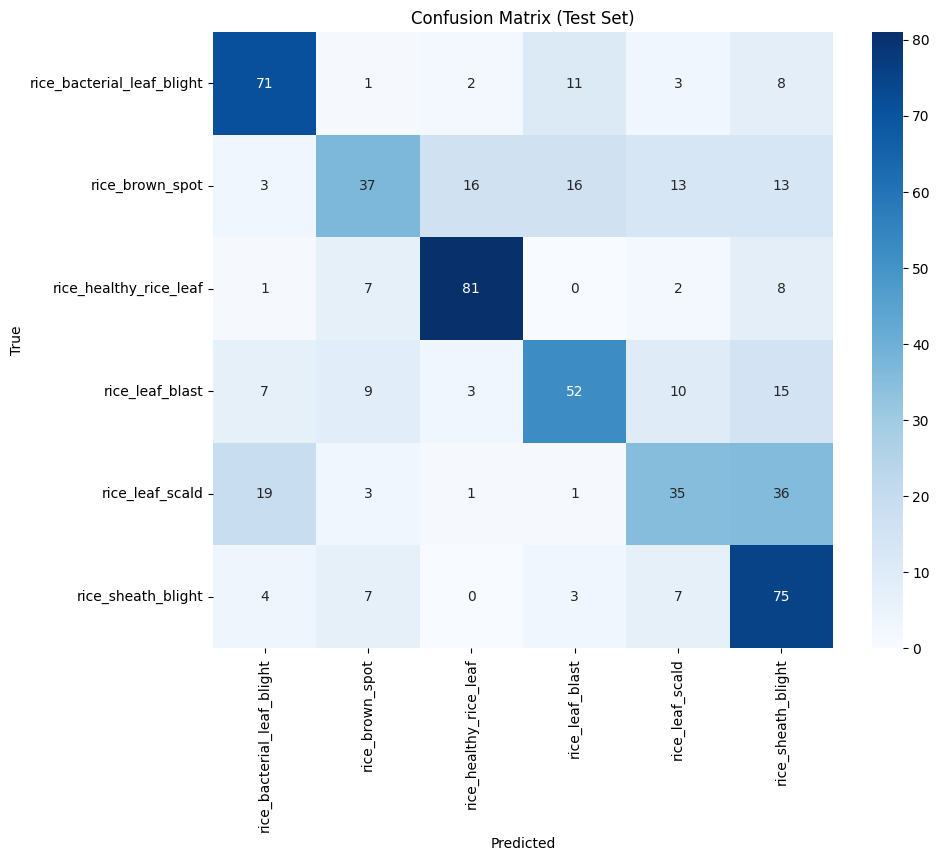

In [ ]:
# ==========================================
# 0. INSTALL & IMPORTS
# ==========================================
!pip install -q kagglehub scikit-learn

import os, shutil, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub

# ==========================================
# 1. DOWNLOAD DATASETS
# ==========================================
print("Downloading datasets...")
rice_root = kagglehub.dataset_download("anshulm257/rice-disease-dataset")
weed_root = kagglehub.dataset_download("fpeccia/weed-detection-in-soybean-crops")

# ==========================================
# 2. LOCATE DATA
# ==========================================
rice_data = rice_root
if len(os.listdir(rice_root)) == 1:
    rice_data = os.path.join(rice_root, os.listdir(rice_root)[0])

# ==========================================
# 3. BUILD MASTER DATASET
# ==========================================
MASTER_DIR = "/content/agri_master"
if os.path.exists(MASTER_DIR):
    shutil.rmtree(MASTER_DIR)
os.makedirs(MASTER_DIR)

# Copy Rice
for disease in os.listdir(rice_data):
    disease_path = os.path.join(rice_data, disease)
    if os.path.isdir(disease_path):
        class_name = "rice_" + disease.lower().replace(" ", "_")
        shutil.copytree(disease_path, os.path.join(MASTER_DIR, class_name))

# Copy Weeds
soy_root = os.path.join(weed_root, "dataset")
for cls in ["broadleaf", "grass"]:
    src = os.path.join(soy_root, cls)
    if os.path.exists(src):
        shutil.copytree(src, os.path.join(MASTER_DIR, f"weed_{cls}"))

# ==========================================
# 4. DATA SPLIT
# ==========================================
SPLIT_DIR = "/content/agri_split"
TRAIN_DIR, VAL_DIR, TEST_DIR = f"{SPLIT_DIR}/train", f"{SPLIT_DIR}/val", f"{SPLIT_DIR}/test"

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d): shutil.rmtree(d)
    os.makedirs(d)

random.seed(42)
for cls in os.listdir(MASTER_DIR):
    files = os.listdir(os.path.join(MASTER_DIR, cls))
    random.shuffle(files)
    n = len(files)
    n_train, n_val = int(n * 0.7), int(n * 0.15)

    for split, f_list in zip([TRAIN_DIR, VAL_DIR, TEST_DIR],
                             [files[:n_train], files[n_train:n_train+n_val], files[n_train+n_val:]]):
        dst = os.path.join(split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in f_list:
            shutil.copy(os.path.join(MASTER_DIR, cls, f), os.path.join(dst, f))

# ==========================================
# 5 & 6. LOAD DATASETS
# ==========================================
IMG_SIZE, BATCH_SIZE = 224, 32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(VAL_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds, val_ds, test_ds = train_ds.prefetch(AUTOTUNE), val_ds.prefetch(AUTOTUNE), test_ds.prefetch(AUTOTUNE)

# ==========================================
# 7. MODEL
# ==========================================
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ==========================================
# 8 & 9. TRAIN & EVALUATE
# ==========================================
model.fit(train_ds, validation_data=val_ds, epochs=20)
print("\nEvaluating test set...")
model.evaluate(test_ds)

# ==========================================
# 10. FIXED CONFUSION MATRIX & REPORT
# ==========================================
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Match classes present in the test set to target names
present_classes = np.unique(y_true)
present_names = [class_names[i] for i in present_classes]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=present_classes, target_names=present_names))

cm = confusion_matrix(y_true, y_pred, labels=present_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=present_names, yticklabels=present_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Test Set)"); plt.show()

In [ ]:
import tensorflow as tf
import os

# No need to load from file if it's already in memory!
# We use the 'model' variable from your previous training cell.

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the TFLite file
with open('agri_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Save the labels so the web app knows the names
# This pulls names directly from your split directory
CLASS_NAMES = sorted(os.listdir('/content/agri_split/train'))
with open('labels.txt', 'w') as f:
    for name in CLASS_NAMES:
        f.write(name + '\n')

print("✅ TFLite Conversion Successful!")
print(f"Classes saved: {CLASS_NAMES}")

Saved artifact at '/tmp/tmpo5_2xao2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  133283688866320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688867088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688867664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688868240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688868624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688866704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688869008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283688868816: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ TFLite Conversion Successful!
Classes saved: ['rice_bacterial_leaf_blight', 'rice_brown_spot', 'rice_healthy_rice_leaf', 'rice_leaf_blast', 'rice_leaf_s

In [ ]:
from pyngrok import ngrok
import os

# 1. OVERWRITE WITH FIXED INDENTATION
with open('app.py', 'w') as f:
    f.write(f"""
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title="Agri-Expert Pro", layout="centered")
st.title("🌱 Agri-Expert: TFLite Diagnostic")

@st.cache_resource
def load_tflite():
    interpreter = tf.lite.Interpreter(model_path="agri_model.tflite")
    interpreter.allocate_tensors()
    return interpreter

interpreter = load_tflite()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

with open('labels.txt', 'r') as f:
    CLASS_NAMES = [line.strip() for line in f.readlines()]

up = st.file_uploader("Upload Leaf/Weed Photo", type=["jpg", "png", "jpeg"])

if up:
    img = Image.open(up).convert("RGB").resize((224, 224))
    st.image(img, width=300, caption="Processed Image")

    # Preprocess
    x = np.array(img).astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)

    # Run TFLite Inference
    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])[0]

    # EVERYTHING BELOW MUST BE INSIDE THE 'IF UP:' BLOCK
    idx = np.argmax(preds)
    result = CLASS_NAMES[idx]
    conf = float(preds[idx]) * 100

    st.divider()
    if "weed" in result.lower():
        st.error(f"**Result: {{result}}**")
    else:
        st.success(f"**Result: {{result}}**")

    st.write(f"Confidence: {{conf:.2f}}%")
    st.progress(int(conf))
""")

# 2. FORCE RESTART TUNNEL
!pkill streamlit
ngrok.kill()
ngrok.set_auth_token("390kIrqQDgDkypjDWb7qksOY0N8_6ddzzRgnqzSkwEGzgy6eG")
public_url = ngrok.connect(8501, proto="http")

print(f"\n🚀 WEB APP LIVE AT: {public_url}")
!streamlit run app.py >/dev/null &


🚀 WEB APP LIVE AT: NgrokTunnel: "https://kia-hexameral-unsoothingly.ngrok-free.dev" -> "http://localhost:8501"


2026-01-31 08:56:52.237236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769849812.312115   50543 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769849812.333511   50543 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769849812.413708   50543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769849812.413778   50543 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769849812.413784   50543 computation_placer.cc:177] computation placer alr

In [ ]:
# ==========================================
# RE-TRAIN: DISCRIMINATIVE WEED FIX
# ==========================================
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(1./255),

    # HEAVY AUGMENTATION to distinguish textures
    layers.RandomContrast(0.3),
    layers.RandomZoom(0.3),
    layers.RandomFlip("horizontal"),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(), # Stabilizes learning
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5), # Prevents cheating/memorization
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slower for better precision
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train again for 15-20 epochs
model.fit(train_ds, validation_data=val_ds, epochs=20)

# RE-CONVERT TO TFLITE IMMEDIATELY
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('agri_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ NEW BRAIN LOADED. Refresh your web app and try that photo again!")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 477s 6s/step - accuracy: 0.3407 - loss: 1.6816 - val_accuracy: 0.1716 - val_loss: 1.9104
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 469s 5s/step - accuracy: 0.5440 - loss: 1.2512 - val_accuracy: 0.2242 - val_loss: 2.1725
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 493s 6s/step - accuracy: 0.5809 - loss: 1.1381 - val_accuracy: 0.1944 - val_loss: 2.9807
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 502s 6s/step - accuracy: 0.6236 - loss: 1.0332 - val_accuracy: 0.2084 - val_loss: 3.4790
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 503s 6s/step - accuracy: 0.6338 - loss: 1.0033 - val_accuracy: 0.1944 - val_loss: 3.6890
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 468s 5s/step - accuracy: 0.6652 - loss: 0.9191 - val_accuracy: 0.2189 - val_loss: 3.0400
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 491s 6s/step - accuracy: 0.6642 - loss: 0.8859 - val_accuracy: 0.4256 - val_loss: 1.7303
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 493s 6s/step - accuracy: 0.6847 - loss: 0.8695 - val_accuracy: 0.5639 - v

In [ ]:
import tensorflow as tf
import os

# 1. Convert current 'model' to TFLite with optimization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Shrinks size
tflite_model = converter.convert()

# 2. Save the TFLite file
with open('agri_model.tflite', 'wb') as f:
    f.write(tflite_model)

# 3. Save labels so the app knows the names
CLASS_NAMES = sorted(os.listdir('/content/agri_split/train'))
with open('labels.txt', 'w') as f:
    for name in CLASS_NAMES:
        f.write(name + '\n')

print("✅ TFLite Conversion Successful!")

Saved artifact at '/tmp/tmpwilkwoq_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  133283683075280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683076048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683076432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683077392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683077200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683076624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683077008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683076240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683075088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133283683078544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13328368307

In [ ]:
from pyngrok import ngrok
import os

# Create the final app script
with open('app.py', 'w') as f:
    f.write(f"""
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title="Agri-Expert Pro", layout="centered")
st.title("🌱 Agri-Expert: TFLite Diagnostic")

# Load TFLite Model
@st.cache_resource
def load_tflite():
    interpreter = tf.lite.Interpreter(model_path="agri_model.tflite")
    interpreter.allocate_tensors()
    return interpreter

interpreter = load_tflite()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Load Labels
with open('labels.txt', 'r') as f:
    CLASS_NAMES = [line.strip() for line in f.readlines()]

up = st.file_uploader("Upload Leaf/Weed Photo", type=["jpg", "png", "jpeg"])

if up:
    img = Image.open(up).convert("RGB").resize((224, 224))
    st.image(img, width=300, caption="Processed Image")

    # Preprocess (Rescale 1./255)
    x = np.array(img).astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)

    # Run TFLite Inference
    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])[0]

    idx = np.argmax(preds)
    result = CLASS_NAMES[idx]
    conf = float(preds[idx]) * 100

    st.divider()
    if "weed" in result.lower():
        st.error(f"**Result: {{result}}**")
    else:
        st.success(f"**Result: {{result}}**")

    st.write(f"Confidence: {{conf:.2f}}%")
    st.progress(int(conf))
""")

# Restart the tunnel
!pkill streamlit
ngrok.kill()
ngrok.set_auth_token("390kIrqQDgDkypjDWb7qksOY0N8_6ddzzRgnqzSkwEGzgy6eG")
public_url = ngrok.connect(8501, proto="http")

print(f"\n🚀 WEBSITE LIVE AT: {public_url}")
!streamlit run app.py >/dev/null &


🚀 WEBSITE LIVE AT: NgrokTunnel: "https://kia-hexameral-unsoothingly.ngrok-free.dev" -> "http://localhost:8501"


2026-01-31 12:07:30.409165: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769861250.765051   96279 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769861250.866515   96279 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769861251.582393   96279 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769861251.582499   96279 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769861251.582507   96279 computation_placer.cc:177] computation placer alr

### Function to Divide Image into Quadrants

This function takes a PIL Image object and returns a list containing the four quadrant images. It assumes the image can be evenly divided, or it will truncate pixels if dimensions are odd.

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def divide_into_quadrants(image):
    """
    Divides a PIL Image into four equal quadrants.

    Args:
        image (PIL.Image.Image): The input image.

    Returns:
        list: A list containing four PIL Image objects representing the quadrants
              (top-left, top-right, bottom-left, bottom-right).
    """
    width, height = image.size
    mid_width = width // 2
    mid_height = height // 2

    # Define the coordinates for each quadrant
    quadrant1 = image.crop((0, 0, mid_width, mid_height))  # Top-left
    quadrant2 = image.crop((mid_width, 0, width, mid_height))  # Top-right
    quadrant3 = image.crop((0, mid_height, mid_width, height))  # Bottom-left
    quadrant4 = image.crop((mid_width, mid_height, width, height)) # Bottom-right

    return [quadrant1, quadrant2, quadrant3, quadrant4]

### Example Usage

Here's an example demonstrating how to use the `divide_into_quadrants` function. We'll create a simple dummy image for this purpose, but you could load any image from your dataset.

In [ ]:
# Create a dummy image for demonstration
dummy_image = Image.fromarray(np.zeros((200, 200, 3), dtype=np.uint8))
# Draw some colored squares in each 'quadrant' for visual clarity

# Top-left (red)
for i in range(100):
    for j in range(100):
        dummy_image.putpixel((i, j), (255, 0, 0))

# Top-right (green)
for i in range(100, 200):
    for j in range(100):
        dummy_image.putpixel((i, j), (0, 255, 0))

# Bottom-left (blue)
for i in range(100):
    for j in range(100, 200):
        dummy_image.putpixel((i, j), (0, 0, 255))

# Bottom-right (yellow)
for i in range(100, 200):
    for j in range(100, 200):
        dummy_image.putpixel((i, j), (255, 255, 0))

print("Original Image:")
plt.imshow(dummy_image)
plt.axis('off')
plt.title('Original Dummy Image')
plt.show()

# Divide the dummy image into quadrants
quadrants = divide_into_quadrants(dummy_image)

# Display the quadrants
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(quadrants[0])
axes[0, 0].set_title('Quadrant 1 (Top-Left)')
axes[0, 0].axis('off')

axes[0, 1].imshow(quadrants[1])
axes[0, 1].set_title('Quadrant 2 (Top-Right)')
axes[0, 1].axis('off')

axes[1, 0].imshow(quadrants[2])
axes[1, 0].set_title('Quadrant 3 (Bottom-Left)')
axes[1, 0].axis('off')

axes[1, 1].imshow(quadrants[3])
axes[1, 1].set_title('Quadrant 4 (Bottom-Right)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()